In [6]:
import os, sys, torch
import numpy as np
import pandas as pd
import scanpy as sc

from torch.utils.data import DataLoader, TensorDataset


In [2]:
from src import _learner, _configure, PATH, _epsilon_module
from src import _diffplot as dfp
from importlib import reload
pj = os.path.join

/home/wergillius/Project/diffuse_differentiate/script/path_n_util.py
/home/wergillius/Project/diffuse_differentiate/machine_config.json


In [3]:
adata_diff = sc.read_h5ad(
    "/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad"
)

# to tensor

In [4]:
TF_onehot = pd.get_dummies(adata_diff.obs.TF).values
gene_X = adata_diff.X
X =  np.concatenate([gene_X, TF_onehot], axis=1)

Y = adata_diff.layers['a3_PathSampled_X'].copy()

train_idx = adata_diff.obs.split != 'test'
test_idx = adata_diff.obs.split == 'test'

x_train = torch.from_numpy(X[train_idx]).float()
x_test = torch.from_numpy(X[test_idx]).float()

Y_train = torch.from_numpy(Y[train_idx]).float()
Y_test = torch.from_numpy(Y[test_idx]).float()

In [5]:
train_ds = TensorDataset(x_train, Y_train)
train_dl = DataLoader(train_ds, batch_size=32, num_workers=8, shuffle=True)

test_ds = TensorDataset(x_test, Y_test)
test_dl = DataLoader(test_ds, batch_size=32,  num_workers=8, shuffle=False)

NameError: name 'TensorDataset' is not defined

# model config and checkpoint

In [66]:
Equiv_config_path = pj(PATH.main_dir,"configs/TF_atlas_Supervised/debug_Equi.yaml")
Equiv_config = _configure.Yaml_configurer(Equiv_config_path)

AE_config_path = pj(PATH.main_dir,"configs/TF_atlas_Supervised/debug_AELearner.yaml")
AE_config = _configure.Yaml_configurer(AE_config_path)

CAE_ckpt = "TF_atlas_Supervised/Epsilon_CAE_debug_AELearner/lightning_logs/version_1"
Equiv_ckpt = "TF_atlas_Supervised/Epsilon_Linear_debug_Equi/lightning_logs/version_0"

In [67]:
Equiv_pl_model = dfp.reload_sampler(Equiv_config_path, 
                                    "TF_atlas_Supervised/Epsilon_Linear_debug_Equi/lightning_logs/version_0",
                                    0)

checkpoint finded
Equivalent_Diffuse_Sampler loaded with module Epsilon_Linear


In [68]:
AE_pl_model = dfp.reload_sampler(AE_config_path, 
                                    "TF_atlas_Supervised/Epsilon_CAE_debug_AELearner/lightning_logs/version_1",
                                    0)

checkpoint finded


AE_learner loaded with module Epsilon_CAE


In [76]:
dl_ls = dfp.dl_from_config(Equiv_config, shuffle=False)

In [77]:
test_dl = dl_ls[2]

# make prediction

In [69]:
import pytorch_lightning as pl

In [70]:
trainer = pl.Trainer(devices=[0], accelerator='gpu', gpus=[0])

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [71]:
reload(dfp)

<module 'src._diffplot' from '/home/wergillius/Project/diffuse_differentiate/src/_diffplot.py'>

In [4]:
Equiv_pred_ad, Equiv_pl_model = dfp.plot_representation(Equiv_config_path,ckpt_path=Equiv_ckpt,device=0)

loadin adata with 28825 cells, which normally takes around 5.54 mins
checkpoint finded
Equivalent_Diffuse_Sampler loaded with module Epsilon_Linear


100%|██████████| 91/91 [00:01<00:00, 87.42it/s] 



cell embedding extracted, ready to computing KNN...

KNN constructed, computing UMAP...

Finished!


In [80]:
Equiv_pl_model = Equiv_pl_model.to('cpu')
Equiv_pl_model.eval();

In [114]:
Equiv_pl_model.model.epsilon_theta.encoder.linear_0.parameters()

<generator object Module.parameters at 0x15526077f510>

In [115]:
AE_pl_model.model.epsilon_theta.encoder.linear_0.parameters()

<generator object Module.parameters at 0x155260339e40>

In [102]:
Y_true = []
Y_pred = []
with torch.no_grad():
    for x, b, condition, y, t in test_dl:
        x = x.to(0)
        condition = condition.to(0)

        # ypred = Equiv_pl_model(x,condition.long(),b,t)
        output = Equiv_pl_model.model(x, condition , None , t)
        Y_pred.append(output.cpu().numpy())
        Y_true.append(y.cpu().numpy())

Y_true = np.concatenate(Y_true, axis=0)
Y_pred = np.concatenate(Y_pred, axis=0)

ValueError: all input arrays must have the same shape

In [74]:
Equiv_ad = dfp.compute_velocity(adata_diff, -1*Equiv_pred_ad.obsm['delta_x'].copy(), n_jobs=20)

computing velocity graph (using 20/48 cores)


  0%|          | 0/28825 [00:00<?, ?cells/s]

    finished (0:00:56) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [56]:
import scvelo as scv

computing velocity embedding


    finished (0:00:06) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


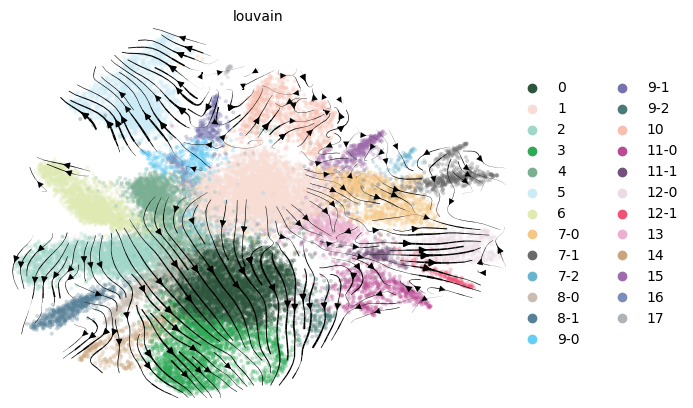

In [75]:
scv.pl.velocity_embedding_stream(Equiv_ad, color='louvain', legend_loc='far right')

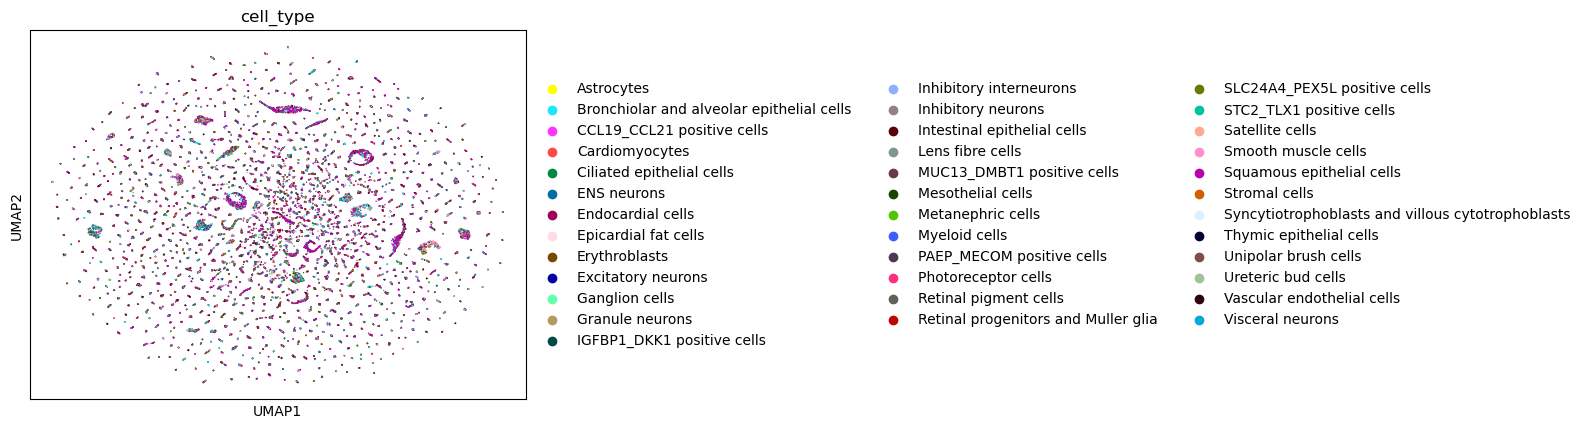

In [9]:
sc.pl.umap(Equiv_pred_ad, color=['cell_type'])

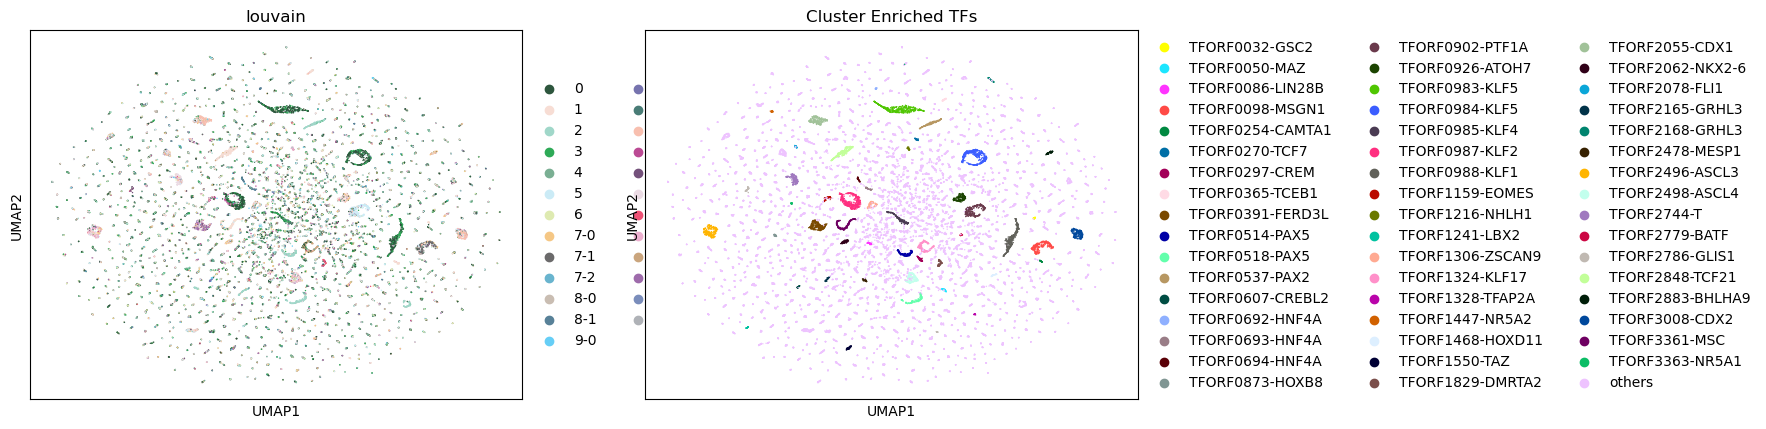

In [12]:
sc.pl.umap(Equiv_pred_ad, color=['louvain','Cluster Enriched TFs'])

In [54]:
AE_pred_ad

AnnData object with n_obs × n_vars = 28825 × 4806
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'discrete_time', 'split', 'cell_type', 'Cluster Enriched TFs_colors', 'highlight_celltype', 'Depth_from_root', 'Cluster Enriched TFs'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'KNN', 'batch_colors', 'diffmap_evals', 'highlight_celltype_colors', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'umap', 'unique_token_dict', 'z_c', 'Cluster Enriched TFs_colors'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap', 'delta_x', 'z_c', 'z', 'c'
    varm: 'PCs'
    layers: 'a2_PathSampled_X', 'a3_PathSampled_X'
    obsp: 'KNN_connectivities', 'KNN_distances', 'connectivities', 'distances', 'z_c_distances', 'z_c_connectivities'

In [38]:
AE_pred_ad, AE_pl_model = dfp.plot_representation(AE_config_path, ckpt_path=CAE_ckpt, device=0)

loadin adata with 28825 cells, which normally takes around 5.54 mins
checkpoint finded
AE_learner loaded with module Epsilon_CAE


100%|██████████| 91/91 [00:01<00:00, 75.36it/s] 



cell embedding extracted, ready to computing KNN...

KNN constructed, computing UMAP...

Finished!


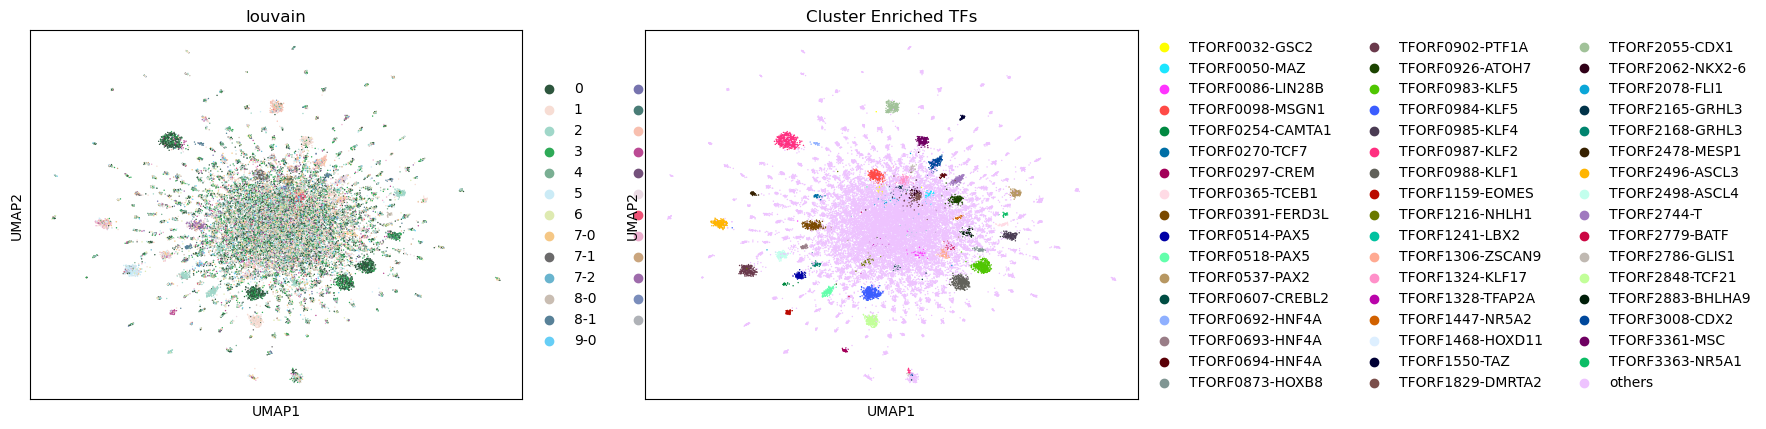

In [40]:
sc.pl.umap(AE_pred_ad, color=['louvain','Cluster Enriched TFs'])

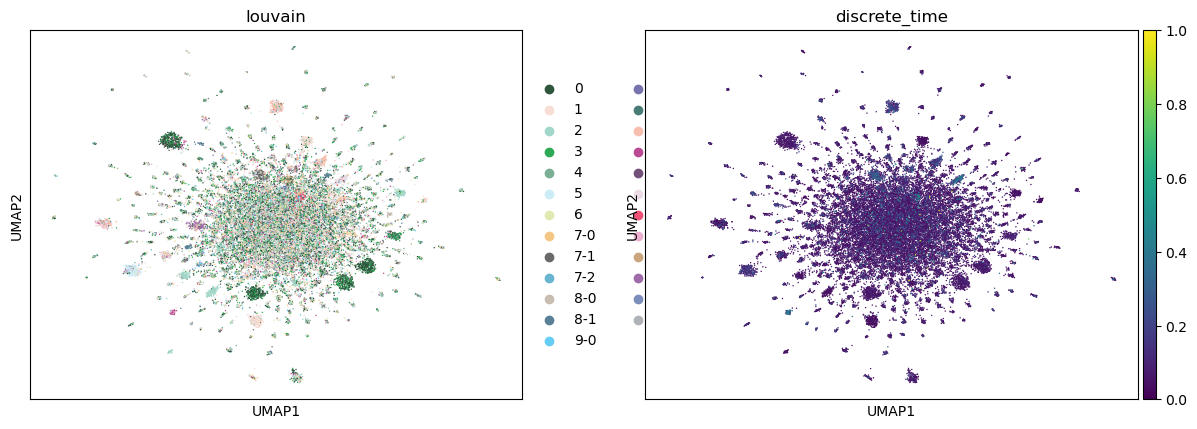

In [41]:
sc.pl.umap(AE_pred_ad, color=['louvain','discrete_time'])

# compute r2

In [35]:
from scipy.stats import pearsonr

In [17]:
test_ad = Equiv_pred_ad[Equiv_pred_ad.obs.split == 'test']
test_Y = test_ad.layers['a3_PathSampled_X'].copy()

In [42]:
AE_ypred = AE_pred_ad[AE_pred_ad.obs.split == 'test'].obsm['delta_x'].copy()
Equiv_ypred = Equiv_pred_ad[Equiv_pred_ad.obs.split == 'test'].obsm['delta_x'].copy()

In [37]:
def evaluate_r(test_Y, pred_Y):

    r_dict = []
    for i, gene in enumerate(test_ad.var.index):
        r_dict.append(
            {"gene":gene, 'r2': pearsonr(test_Y[:,i], pred_Y[:,i])[0]**2}
        )

    return pd.json_normalize(r_dict)

In [49]:
AE_df = evaluate_r(test_Y, AE_ypred)

In [52]:
Equiv_df = evaluate_r(test_Y, Equiv_ypred)

In [106]:
Equiv_df = evaluate_r(Y_true,Y_pred)

In [107]:
Equiv_df

,gene,r2
0,A2M,0.000414
1,AADACL3,0.000020
2,ABCA1,0.000038
3,ABCA12,0.000823
4,ABCA13,0.000078
...,...,...
4801,ZRANB3,0.000136
4802,ZRSR2,0.000841
4803,ZSCAN1,0.000158
4804,ZSWIM6,0.000880


In [51]:
AE_df

,gene,r2
0,A2M,0.001177
1,AADACL3,0.000011
2,ABCA1,0.000619
3,ABCA12,0.000197
4,ABCA13,0.001035
...,...,...
4801,ZRANB3,0.000013
4802,ZRSR2,0.000004
4803,ZSCAN1,0.000039
4804,ZSWIM6,0.000165
